# What is Principal Component Analysis?
By: Marisol Fermin Flores, M.S

Principal Component Analysis (PCA) is a dimensionality reduction method. It transforms high-dimensional data into a smaller number of new variables called **principal components**.

These components are ordered by how much variation they explain:
the first component captures the most variation, the second captures the next most, and so on.

Watch this short video for an intuitive visual explanation of PCA:
https://youtu.be/5vgP05YpKdE?si=-A2yVN-Ar-K0GUzR

In population genetics, PCA is often used to visualize genetic similarity among individuals. Samples that cluster together are more genetically similar, while samples that separate from one another may reflect differences in ancestry, population history, or geographic origin.

In this tutorial, we use PCA to check whether samples cluster according to their population label (**FID**) and to see how much of the overall variation is explained by the first few principal components, especially **PC1** and **PC2**.

- **PC1** captures the largest amount of variation in the dataset.
- **PC2** captures the second largest amount of variation and is independent of PC1.
- **PC3 and beyond** capture progressively smaller amounts of variation.

Because PCA compresses information into just a few axes, it is especially useful for making complex genetic data easier to visualize and interpret.

We will use the Mendeley Data set **"Genotype Data for a set of 163 worldwide populations"**:
https://data.mendeley.com/datasets/ckz9mtgrjj/4

The PLINK binary files (`.bed`, `.bim`, `.fam`) were downloaded and processed with standard quality-control steps, including filtering and linkage disequilibrium (LD) pruning. After preprocessing, PCA was performed and the top 20 principal components were generated for downstream analysis.

### Note on the workflow

In a typical PCA analysis, we start with **raw genotype data**, apply quality-control steps, and then run PCA to compute the principal component coordinates. Those coordinates are what we usually plot.

The workflow usually looks like this:

```text
Raw genotype data
   ↓
Quality control (QC)
   ↓
LD pruning
   ↓
PCA computation
   ↓
PC coordinates (PC1, PC2, PC3, ...)
   ↓
Visualization and interpretation
```

In this tutorial, the PCA step has **already been completed**. We begin with the output files (`Busby_PCA20.csv` and the corresponding eigenvalues) and focus on merging the coordinates with metadata, interpreting the variance explained, and plotting the results.

# Step 1: Import libraries and connect to Google Drive

In [ ]:
# Install packages once if needed
# !pip install pandas matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

from google.colab import drive
drive.mount('/content/drive')


# Step 2: Read the PCA file and metadata file

The PCA file contains the principal component coordinates for each sample.
The metadata file contains the population or group labels that we want to match to each sample.

You will need to download the data and upload it to your google drive and specify the location in the paths below.


In [ ]:
pca_path = "/content/drive/MyDrive/ColabNotebooks/scip/mendeleyData/Busby_PCA20.csv"

pop_geo = ("/content/drive/MyDrive/ColabNotebooks/scip/mendeleyData/Master_data_Busby.csv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Step 3: Read the PCA coordinates



In [ ]:
# PLINK eigenvec-style files often do not include a header row.
# If your file already has headers, remove header=None.
pc_cols = [f"PC{i}" for i in range(1, 21)]

BusbyPCA = pd.read_csv(pca_path, header=None)
BusbyPCA.columns = ["FID", "IID"] + pc_cols

BusbyPCA.head()

,FID,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,...,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
0,abhkasian,abh9,-0.008158,0.013961,-0.004142,0.006412,-0.012798,-0.001356,0.013798,-0.017906,...,-0.000200,-0.013174,-0.003854,0.027632,-0.004558,0.003471,-0.020305,0.001832,-0.008670,-0.001309
1,abhkasian,abh24,-0.006867,0.014163,-0.005837,0.006823,-0.015174,0.000754,0.011714,-0.012923,...,-0.002016,-0.011519,-0.011281,0.026746,0.000442,0.004386,-0.016992,-0.006695,-0.001796,0.002391
2,abhkasian,abh27,-0.008989,0.013895,-0.003879,0.004362,-0.013426,-0.000910,0.011853,-0.015567,...,-0.000124,-0.013286,-0.009992,0.033303,-0.005457,-0.001039,-0.017643,-0.003588,-0.004933,-0.000107
3,abhkasian,abh41,-0.009375,0.013775,-0.003370,0.005893,-0.013707,-0.003650,0.012292,-0.014415,...,-0.003962,-0.005713,-0.006108,0.027468,-0.005414,-0.001890,-0.018977,0.005518,-0.005497,-0.004018
4,abhkasian,abh45,-0.008266,0.014160,-0.003940,0.005165,-0.012709,0.000327,0.014351,-0.012676,...,-0.005374,-0.011131,-0.013559,0.029526,0.001919,0.006215,-0.019090,-0.009486,-0.005683,0.003124


# Step 4: Read the geographic metadata and merge it with the PCA data

In [ ]:
Busby_Geo = pd.read_csv(pop_geo)
print(Busby_Geo)

            FID        IID Continent
0     abhkasian       abh9   Eurasia
1     abhkasian      abh24   Eurasia
2     abhkasian      abh27   Eurasia
3     abhkasian      abh41   Eurasia
4     abhkasian      abh45   Eurasia
...         ...        ...       ...
2638     yoruba  HGDP00943    Africa
2639    yukagir   Yukagir4      Asia
2640    yukagir   Yukagir5      Asia
2641    yukagir   Yukagir6      Asia
2642    yukagir   Yukagir9      Asia

[2643 rows x 3 columns]


We merge the PCA table and the metadata using **FID** and **IID** so that each point in the PCA plot receives the correct population label.

This merge step is essential because PCA gives us coordinates, but the metadata tells us which group each sample belongs to.

In [ ]:
# Merge the PCA coordinates with the population metadata
BusbyPCA_merge = pd.merge(BusbyPCA, Busby_Geo, on=["FID", "IID"])
BusbyPCA_merge.head()

# Step 5: Read the eigenvalues and convert them into percentages

Eigenvalues tell us how much variation each principal component explains. Converting them into percentages makes the axis labels easier to read and interpret.

For example, if PC1 explains 18% of the variation, then the points spread along the x-axis are showing the strongest source of structure in the data.

In [ ]:
eigenval = pd.read_csv("/content/drive/MyDrive/ColabNotebooks/scip/mendeleyData/Busby_PCA20.eigenval.csv", header=None)
eigenval.columns = ["Eigenvalue"]

# Convert to percentage
eigenval["Percent"] = eigenval["Eigenvalue"] / eigenval["Eigenvalue"].sum() * 100
print(eigenval)

pc1_pct = eigenval.loc[0, "Percent"]
pc2_pct = eigenval.loc[1, "Percent"]

    Eigenvalue    Percent
0     83.34530  31.454778
1     70.88690  26.752939
2     18.60670   7.022227
3     15.89050   5.997125
4     11.28560   4.259221
5     10.68030   4.030779
6      8.55203   3.227563
7      6.15946   2.324600
8      5.11568   1.930674
9      4.27244   1.612432
10     3.81241   1.438815
11     3.45333   1.303298
12     3.40615   1.285492
13     3.26858   1.233572
14     2.97301   1.122023
15     2.91636   1.100643
16     2.72274   1.027571
17     2.56352   0.967480
18     2.54137   0.959121
19     2.51627   0.949648


# Step 6: Plot the PCA

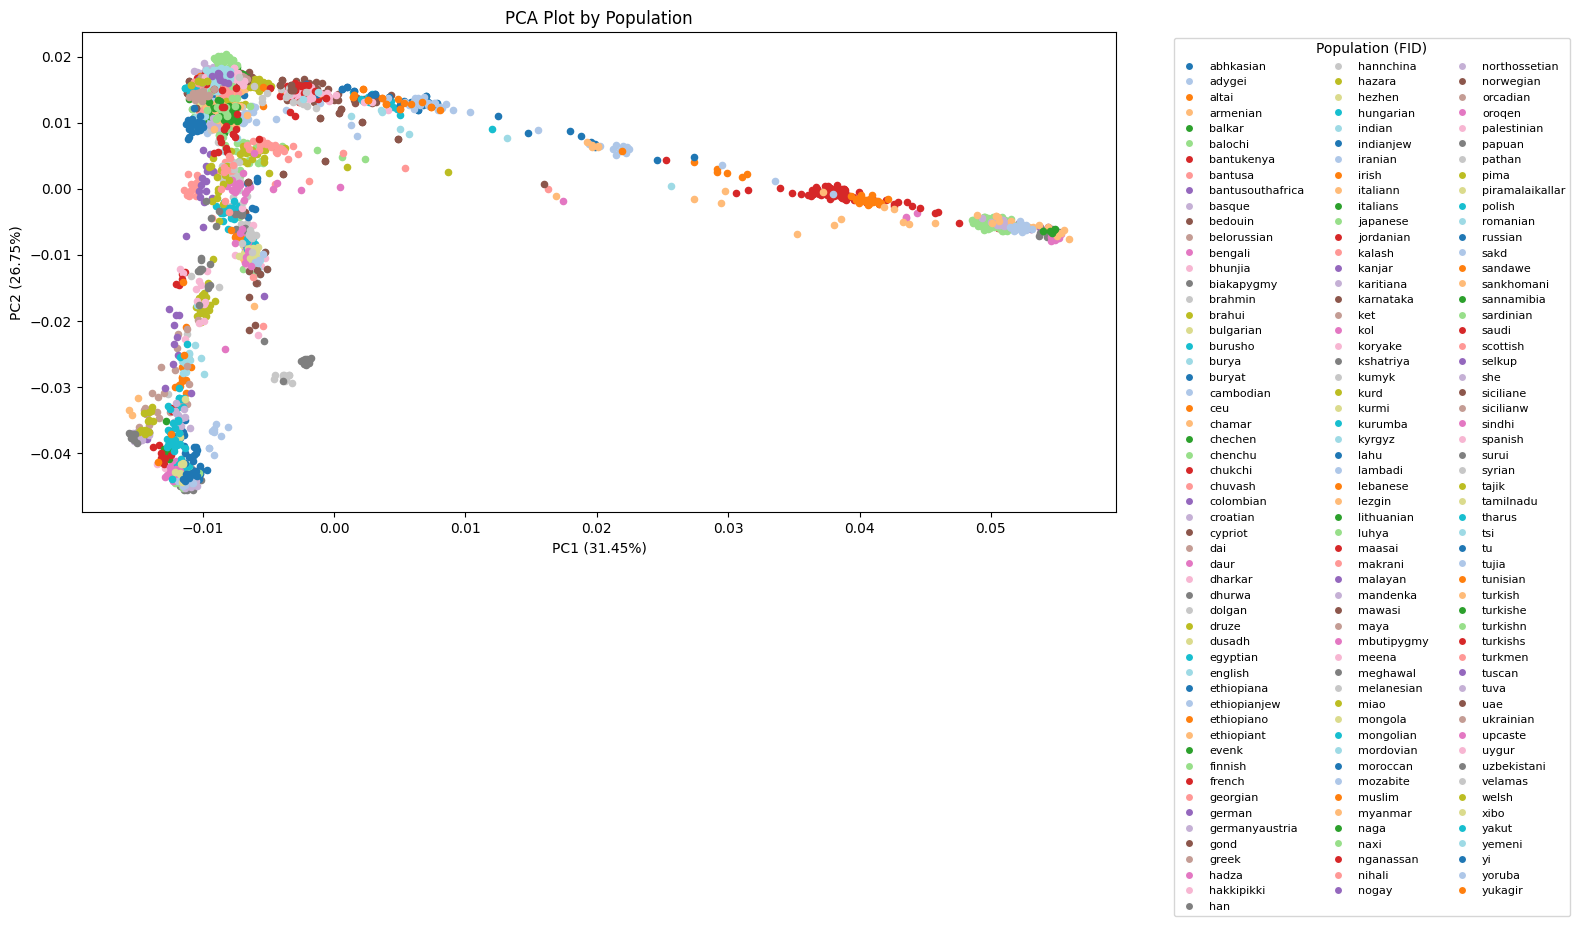

In [ ]:
# Get all population names (FID)
fids = sorted(BusbyPCA_merge["FID"].dropna().unique())

# Choose a color palette
colors = mpl.colormaps["tab20"]

# Make the plot
plt.figure(figsize=(16, 8))

for i, fid in enumerate(fids):
    # Get data for one population
    data = BusbyPCA_merge[BusbyPCA_merge["FID"] == fid]

    # Plot PC1 vs PC2
    plt.scatter(
        data["PC1"],
        data["PC2"],
        color=colors(i % 20),
        s=20,
        alpha=0.85
    )

# Add labels and title
plt.xlabel(f"PC1 ({pc1_pct:.2f}%)")
plt.ylabel(f"PC2 ({pc2_pct:.2f}%)")
plt.title("PCA Plot by Population")
plt.grid(True, linestyle="--", alpha=0.25)

# Create a custom legend
legend = []
for i, fid in enumerate(fids):
    legend.append(
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            label=fid,
            markerfacecolor=colors(i % 20),
            markersize=6
        )
    )

plt.legend(
    handles=legend,
    title="Population (FID)",
    ncol=3,
    fontsize=8,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.savefig("PCA_plot.png", dpi=300, bbox_inches="tight")
plt.show()

## Your turn

Rerun the analysis using **PC2 vs. PC3** instead of **PC1 vs. PC2**.

Then compare the two plots:
- Does the pattern of clustering change?
- Do some populations separate more clearly in PC2/PC3?
- Why might the PC1/PC2 plot look different from the PC2/PC3 plot?

A useful interpretation is that **PC1/PC2** usually captures the strongest overall structure in the data, while **PC2/PC3** shows more subtle variation after the first axis of variation has already been removed.



## Optional toy example: from PLINK files to a PCA plot

In a real analysis, the raw input is often a set of PLINK files:

- **`.fam`**: sample information
- **`.bim`**: variant information
- **`.bed`**: the binary genotype matrix

The `.bed` file is not human-readable, so in this toy example we show the same idea using a small genotype matrix that would be stored in `.bed`, along with simplified `.fam` and `.bim` tables. The workflow is:

1. read sample metadata from `.fam`
2. read variant metadata from `.bim`
3. read genotype calls from `.bed`
4. run PCA
5. plot the first two PCs

This is only a toy illustration, but it matches the structure of the real workflow used before plotting.

Toy .fam table:


,FID,IID,PAT,MAT,SEX,PHENOTYPE
0,AFR1,AFR1,0,0,1,-9
1,AFR2,AFR2,0,0,2,-9
2,EUR1,EUR1,0,0,1,-9
3,EUR2,EUR2,0,0,2,-9
4,EAS1,EAS1,0,0,1,-9
5,EAS2,EAS2,0,0,2,-9


Toy .bim table:


,CHR,SNP,CM,BP,A1,A2
0,1,rs1,0,101,A,G
1,1,rs2,0,205,G,A
2,1,rs3,0,310,T,C
3,1,rs4,0,420,C,T
4,1,rs5,0,530,A,C
5,1,rs6,0,640,G,T


Genotype matrix (what would be encoded in .bed):


SNP,rs1,rs2,rs3,rs4,rs5,rs6
IID,,,,,,
AFR1,0,0,0,1,0,1
AFR2,0,1,0,1,0,1
EUR1,1,1,1,1,1,2
EUR2,1,2,1,2,1,2
EAS1,2,2,2,1,2,1
EAS2,2,1,2,0,2,0


PCA coordinates:


,PC1,PC2,FID
IID,,,
AFR1,-2.353496,-1.310690,AFR1
AFR2,-1.928776,-0.536303,AFR2
EUR1,-0.336946,0.571007,EUR1
EUR2,-0.318131,2.395656,EUR2
EAS1,2.318386,0.772532,EAS1
EAS2,2.618963,-1.892203,EAS2


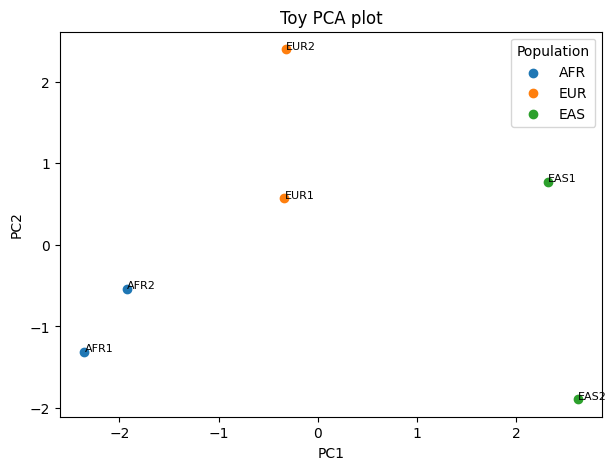

Explained variance ratio:
[0.60299278 0.3402217 ]


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# -------------------------------------------------------------------
# Toy PLINK-style input
# -------------------------------------------------------------------
# .fam-like sample table
fam = pd.DataFrame({
    "FID": ["AFR1", "AFR2", "EUR1", "EUR2", "EAS1", "EAS2"],
    "IID": ["AFR1", "AFR2", "EUR1", "EUR2", "EAS1", "EAS2"],
    "PAT": [0, 0, 0, 0, 0, 0],
    "MAT": [0, 0, 0, 0, 0, 0],
    "SEX": [1, 2, 1, 2, 1, 2],
    "PHENOTYPE": [-9, -9, -9, -9, -9, -9],
})

# .bim-like variant table
bim = pd.DataFrame({
    "CHR": [1, 1, 1, 1, 1, 1],
    "SNP": ["rs1", "rs2", "rs3", "rs4", "rs5", "rs6"],
    "CM": [0, 0, 0, 0, 0, 0],
    "BP": [101, 205, 310, 420, 530, 640],
    "A1": ["A", "G", "T", "C", "A", "G"],
    "A2": ["G", "A", "C", "T", "C", "T"],
})

# Toy genotype matrix (this would usually come from the .bed file)
# Values represent allele counts: 0, 1, or 2 copies of the effect allele
genotypes = pd.DataFrame(
    [
        [0, 0, 0, 1, 0, 1],  # AFR1
        [0, 1, 0, 1, 0, 1],  # AFR2
        [1, 1, 1, 1, 1, 2],  # EUR1
        [1, 2, 1, 2, 1, 2],  # EUR2
        [2, 2, 2, 1, 2, 1],  # EAS1
        [2, 1, 2, 0, 2, 0],  # EAS2
    ],
    columns=bim["SNP"],
    index=fam["IID"],
)

print("Toy .fam table:")
display(fam)

print("Toy .bim table:")
display(bim)

print("Genotype matrix (what would be encoded in .bed):")
display(genotypes)

# -------------------------------------------------------------------
# PCA on the genotype matrix
# -------------------------------------------------------------------
# Center and scale each SNP so the PCA is not dominated by variants with
# larger numeric ranges or missing scaling assumptions.
X = genotypes.astype(float)
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pcs,
    columns=["PC1", "PC2"],
    index=fam["IID"],
)
pca_df["FID"] = fam["FID"].values

print("PCA coordinates:")
display(pca_df)

# -------------------------------------------------------------------
# Plot PCA results
# -------------------------------------------------------------------

# Population labels from the FID column
pca_df["Population"] = pca_df["FID"].str[:3]

plt.figure(figsize=(7, 5))

for pop in pca_df["Population"].unique():
    subset = pca_df[pca_df["Population"] == pop]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=pop
    )

    # Add sample labels
    for sample in subset.index:
        plt.text(
            subset.loc[sample, "PC1"],
            subset.loc[sample, "PC2"],
            sample,
            fontsize=8
        )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Toy PCA plot")
plt.legend(title="Population")
plt.show()

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)